# Exploração territorial de CVLI no Ceará (2009–2025)

Análise exploratória acadêmica, descritiva e reproduzível da aba `CVLI` do arquivo `data/CVLI_2009-a-2025.xlsx`.

**Pergunta central:** como o volume de registros de Crimes Violentos Letais Intencionais se concentra e persiste entre municípios e Regiões de Planejamento?

**Unidade disponível:** cada linha da aba `CVLI` é tratada como um registro de ocorrência/vítima. Não há deduplicação automática.

## tl;dr

A base contém 59.340 registros de CVLI entre 2009 e 2025. O painel completo possui 3.128 combinações município–ano, preserva a soma dos registros e inclui 289 combinações com zero.

O maior volume anual ocorreu em 2017 (5.133 registros). A concentração nos cinco municípios líderes foi maior em 2009–2012 (59,39%), enquanto Fortaleza e Caucaia apareceram entre os cinco maiores volumes em todos os 17 anos. Os resultados são contagens de registros, não taxas populacionais.

## Context & Methods

### Escopo

- A análise usa exclusivamente a aba `CVLI`; as abas `Intervenção Policial` e `Unidade Prisional` permanecem fora do escopo.
- O indicador principal é o **volume de registros**, não uma taxa populacional. Portanto, os resultados não devem ser chamados de “municípios mais violentos” sem um denominador populacional.
- A análise é descritiva: não estima causalidade, impacto de políticas ou risco futuro.

### Key Assumptions

- Municípios sem linha em determinado ano são incluídos no painel como `total_cvli = 0` e marcados com `tem_registro = False`.
- Para comparação entre blocos de tamanhos diferentes, a métrica principal é a média anual de registros; o volume acumulado é mantido como complemento operacional.
- Os blocos temporais são 2009–2012, 2013–2016, 2017–2020 e 2021–2025.
- A população poderá ser anexada futuramente por `code_muni` e `ano`, sem alterar o painel principal.

## Data

### 1. Carregamento explícito das fontes locais

In [1]:
from pathlib import Path
import os
import sys
import warnings

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.matplotlib'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sys.path.insert(0, str(PROJECT_ROOT))

from src.data import (
    clean_column_names,
    load_cvli_data,
    load_municipality_geodata,
    load_planning_regions,
    prepare_planning_regions,
)
from src.features import (
    add_fixed_periods,
    add_population_rates,
    build_municipality_year_panel,
    calculate_concentration_metrics,
    calculate_period_metrics,
    create_age_groups,
    validate_cvli_data,
)
from src.visualization import plot_municipality_period_maps

sns.set_theme(style='whitegrid', context='notebook')
warnings.filterwarnings('ignore', category=UserWarning)

DATA_DIR = PROJECT_ROOT / 'data'
CVLI_FILE = DATA_DIR / 'CVLI_2009-a-2025.xlsx'
REGIONS_FILE = DATA_DIR / 'Lista_Regioes_Planejamento_Ceara (1).xlsx'

workbook = pd.ExcelFile(CVLI_FILE)
print('Abas disponíveis:', workbook.sheet_names)
assert workbook.sheet_names[0] == 'CVLI', 'A primeira aba esperada deve ser CVLI.'

# Carregamento intencional: a análise usa somente a aba CVLI.
df_raw = load_cvli_data(filename=CVLI_FILE.name, sheet_name=0)
planning_raw = load_planning_regions(filename=REGIONS_FILE.name)
df = clean_column_names(df_raw)
planning = prepare_planning_regions(planning_raw)

print(f'Base CVLI carregada: {df.shape[0]:,} linhas e {df.shape[1]} colunas.')
print(f'Mapeamento regional: {len(planning):,} municípios.')
display(df.head())
display(df.dtypes.rename('dtype').to_frame())

Abas disponíveis: ['CVLI', 'Intervenção Policial', 'Unidade Prisional']
Base CVLI carregada: 59,340 linhas e 7 colunas.
Mapeamento regional: 184 municípios.


,município,natureza,data,idade_da_vítima,escolaridade_da_vítima,raça_da_vítima,ano
0,Fortaleza,HOMICIDIO DOLOSO,2009-01-01,Não Informada,Não Informada,Não Informada,2009
1,Carnaubal,HOMICIDIO DOLOSO,2009-01-01,Não Informada,Não Informada,Não Informada,2009
2,Quixadá,HOMICIDIO DOLOSO,2009-01-01,Não Informada,Não Informada,Não Informada,2009
3,Baturité,HOMICIDIO DOLOSO,2009-01-01,Não Informada,Não Informada,Não Informada,2009
4,Maracanaú,HOMICIDIO DOLOSO,2009-01-01,Não Informada,Não Informada,Não Informada,2009


,dtype
município,object
natureza,object
data,datetime64[ns]
idade_da_vítima,object
escolaridade_da_vítima,object
raça_da_vítima,object
ano,int64


### 2. Diagnóstico de qualidade, cobertura e unidade de observação

In [2]:
diagnostics = validate_cvli_data(df, planning_raw)

diagnostics_summary = pd.Series({
    'linhas': diagnostics['rows'],
    'colunas': diagnostics['columns'],
    'municípios observados': diagnostics['municipalities'],
    'primeiro ano': min(diagnostics['years']),
    'último ano': max(diagnostics['years']),
    'datas inválidas': diagnostics['date_invalid_count'],
    'inconsistências Data x ano': diagnostics['year_date_mismatch_count'],
    'linhas duplicadas exatas': diagnostics['duplicate_rows'],
}).to_frame('valor')
display(diagnostics_summary)

print('Valores ausentes por coluna:')
display(diagnostics['missing'])

non_informed_rows = []
for column in ['idade_da_vítima', 'escolaridade_da_vítima', 'raça_da_vítima']:
    normalized = df[column].astype('string').str.strip().str.casefold()
    not_informed = normalized.isin({'não informada', 'não informado', ''})
    non_informed_rows.append({
        'coluna': column,
        'registros não informados': int(not_informed.sum()),
        'registros válidos': int((~not_informed).sum()),
        'cobertura válida (%)': round((~not_informed).mean() * 100, 2),
    })
demographic_coverage = pd.DataFrame(non_informed_rows)
display(demographic_coverage)

duplicate_key = ['município', 'natureza', 'data', 'idade_da_vítima', 'escolaridade_da_vítima', 'raça_da_vítima']
print('Duplicidades na chave disponível (sem identificador único de evento):', int(df.duplicated(duplicate_key).sum()))
print('Municípios presentes na base e ausentes no mapeamento regional:', diagnostics['municipalities_not_in_planning'])

assert diagnostics['date_invalid_count'] == 0
assert diagnostics['year_date_mismatch_count'] == 0
assert diagnostics['municipalities_not_in_planning'] == []

,valor
linhas,59340
colunas,7
municípios observados,184
primeiro ano,2009
último ano,2025
datas inválidas,0
inconsistências Data x ano,0
linhas duplicadas exatas,1418


Valores ausentes por coluna:


,missing_count,missing_pct
município,0,0.0
natureza,0,0.0
data,0,0.0
idade_da_vítima,0,0.0
escolaridade_da_vítima,0,0.0
raça_da_vítima,0,0.0
ano,0,0.0


,coluna,registros não informados,registros válidos,cobertura válida (%)
0,idade_da_vítima,5134,54206,91.35
1,escolaridade_da_vítima,16876,42464,71.56
2,raça_da_vítima,46119,13221,22.28


Duplicidades na chave disponível (sem identificador único de evento): 1418
Municípios presentes na base e ausentes no mapeamento regional: []


## Results

### 3. Painel completo município–ano

In [3]:
panel = build_municipality_year_panel(df, planning_raw)
panel = add_fixed_periods(panel)

panel_summary = pd.Series({
    'linhas do painel': len(panel),
    'municípios': panel['code_muni'].nunique(),
    'anos': panel['ano'].nunique(),
    'soma dos registros no painel': int(panel['total_cvli'].sum()),
    'combinações com zero': int((panel['total_cvli'] == 0).sum()),
    'combinações com registro': int(panel['tem_registro'].sum()),
}).to_frame('valor')
display(panel_summary)
display(panel.head())

assert len(panel) == 184 * 17
assert panel['code_muni'].nunique() == 184
assert panel['ano'].nunique() == 17
assert panel['total_cvli'].sum() == len(df)
assert not panel.duplicated(['code_muni', 'ano']).any()

,valor
linhas do painel,3128
municípios,184
anos,17
soma dos registros no painel,59340
combinações com zero,289
combinações com registro,2839


,code_muni,municipio,regiao_planejamento,ano,total_cvli,tem_registro,periodo
0,2300101,Abaiara,Cariri,2009,0,False,2009–2012
1,2300101,Abaiara,Cariri,2010,0,False,2009–2012
2,2300101,Abaiara,Cariri,2011,0,False,2009–2012
3,2300101,Abaiara,Cariri,2012,2,True,2009–2012
4,2300101,Abaiara,Cariri,2013,0,False,2013–2016


### 4. Evolução anual, concentração e persistência territorial

In [4]:
annual_state = (
    panel.groupby('ano', as_index=False)
    .agg(total_cvli=('total_cvli', 'sum'), municipios_com_registro=('tem_registro', 'sum'))
)
annual_state['variacao_pct'] = annual_state['total_cvli'].pct_change().mul(100).round(2)

period_metrics = calculate_period_metrics(panel)
concentration = calculate_concentration_metrics(period_metrics)

# Ranking anual e frequência entre os cinco maiores volumes de cada ano.
annual_rank = panel.copy()
annual_rank['ranking_ano'] = annual_rank.groupby('ano')['total_cvli'].rank(
    method='min', ascending=False
)
top5_persistence = (
    annual_rank.assign(top5=annual_rank['ranking_ano'].le(5))
    .groupby(['code_muni', 'municipio'], as_index=False)
    .agg(anos_no_top5=('top5', 'sum'), anos_com_registro=('tem_registro', 'sum'), total_cvli=('total_cvli', 'sum'))
    .sort_values(['anos_no_top5', 'total_cvli'], ascending=False)
)

print('Evolução anual do volume de registros:')
display(annual_state)
print('Concentração por bloco temporal:')
display(concentration)
print('Municípios com maior persistência entre os cinco maiores volumes anuais:')
display(top5_persistence.head(15))

Evolução anual do volume de registros:


,ano,total_cvli,municipios_com_registro,variacao_pct
0,2009,2262,150,NaN
1,2010,2803,161,23.92
2,2011,2806,161,0.11
3,2012,3730,165,32.93
4,2013,4395,166,17.83
5,2014,4439,172,1.00
6,2015,4019,170,-9.46
7,2016,3407,171,-15.23
8,2017,5133,168,50.66
9,2018,4518,170,-11.98


Concentração por bloco temporal:


,periodo,total_cvli,municipios_com_registro,top_1_pct,top_5_pct,top_10_pct,hhi
0,2009–2012,11601,184,44.46,59.39,65.55,2065.90
1,2013–2016,16260,181,40.97,56.13,62.96,1770.21
2,2017–2020,15947,182,33.69,51.98,61.01,1273.05
3,2021–2025,15532,182,26.17,44.33,52.60,823.79


Municípios com maior persistência entre os cinco maiores volumes anuais:


,code_muni,municipio,anos_no_top5,anos_com_registro,total_cvli
58,2304400,Fortaleza,17,17,21256
43,2303709,Caucaia,17,17,4052
103,2307650,Maracanaú,17,17,2825
98,2307304,Juazeiro do Norte,13,17,1673
166,2312908,Sobral,10,17,1371
104,2307700,Maranguape,4,17,1036
11,2301000,Aquiraz,4,17,970
50,2304202,Crato,2,17,749
154,2311801,Russas,1,17,601
87,2306405,Itapipoca,1,17,498


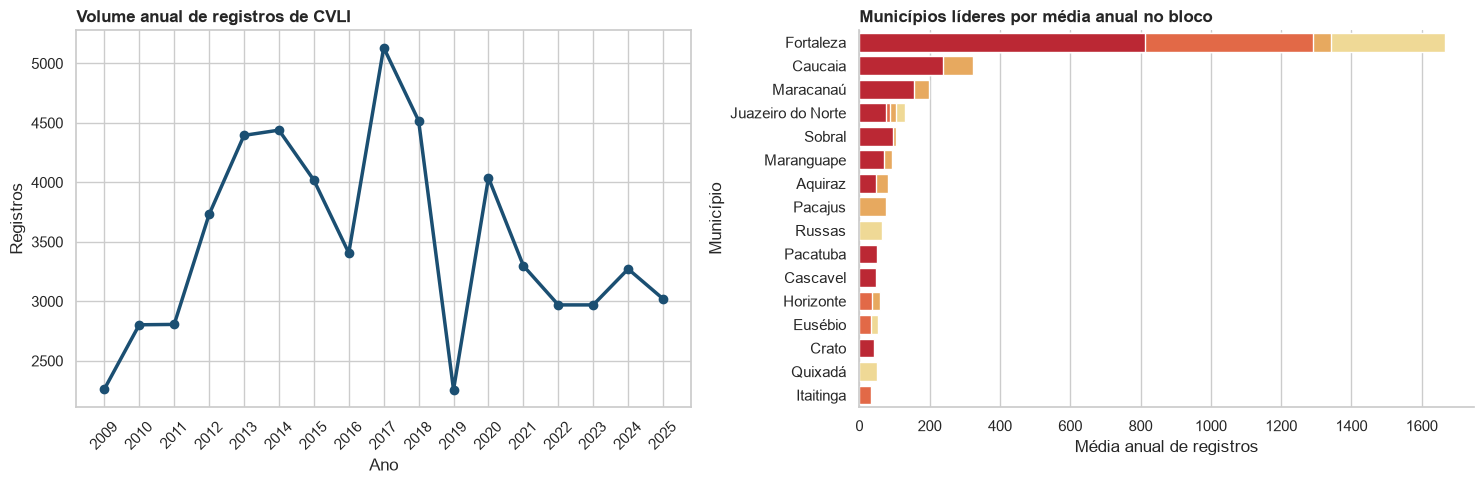

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(annual_state['ano'], annual_state['total_cvli'], marker='o', color='#1b4f72', linewidth=2.5)
axes[0].set_title('Volume anual de registros de CVLI', loc='left', fontweight='bold')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Registros')
axes[0].set_xticks(annual_state['ano'])
axes[0].tick_params(axis='x', rotation=45)

top10 = period_metrics.sort_values('total_cvli', ascending=False).groupby('periodo').head(10)
sns.barplot(
    data=top10,
    y='municipio',
    x='media_anual_cvli',
    hue='periodo',
    dodge=False,
    ax=axes[1],
    palette='YlOrRd',
    legend=False,
)
axes[1].set_title('Municípios líderes por média anual no bloco', loc='left', fontweight='bold')
axes[1].set_xlabel('Média anual de registros')
axes[1].set_ylabel('Município')
axes[1].grid(axis='y', visible=False)
axes[1].spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 5. Comparação entre Regiões de Planejamento

In [6]:
region_sizes = planning.groupby('regiao_planejamento')['code_muni'].nunique().rename('municipios_na_regiao')
region_annual = (
    panel.groupby(['regiao_planejamento', 'ano'], as_index=False)
    .agg(
        total_cvli=('total_cvli', 'sum'),
        municipios_com_registro=('tem_registro', 'sum'),
    )
)
region_annual = region_annual.merge(region_sizes, on='regiao_planejamento', how='left', validate='many_to_one')
region_annual['media_anual_por_municipio'] = (
    region_annual['total_cvli'] / region_annual['municipios_na_regiao']
).round(2)
region_period = (
    panel.groupby(['periodo', 'regiao_planejamento'], as_index=False)
    .agg(
        total_cvli=('total_cvli', 'sum'),
        municipios_com_registro=('tem_registro', 'sum'),
    )
)
period_lengths = panel.groupby('periodo')['ano'].nunique().rename('anos_no_periodo')
region_period = region_period.merge(period_lengths, on='periodo', how='left', validate='many_to_one')
region_period = region_period.merge(region_sizes, on='regiao_planejamento', how='left', validate='many_to_one')
region_period['media_anual_cvli'] = (region_period['total_cvli'] / region_period['anos_no_periodo']).round(2)
region_period['media_anual_por_municipio'] = (
    region_period['total_cvli'] / region_period['anos_no_periodo'] / region_period['municipios_na_regiao']
).round(2)
display(region_period.sort_values(['periodo', 'total_cvli'], ascending=[True, False]))

,periodo,regiao_planejamento,total_cvli,municipios_com_registro,anos_no_periodo,municipios_na_regiao,media_anual_cvli,media_anual_por_municipio
2,2009–2012,Grande Fortaleza,7548,75,4,19,1887.00,99.32
0,2009–2012,Cariri,989,100,4,29,247.25,8.53
13,2009–2012,Vale do Jaguaribe,479,49,4,15,119.75,7.98
8,2009–2012,Sertão Central,422,49,4,13,105.50,8.12
5,2009–2012,Litoral Oeste / Vale do Curu,369,44,4,12,92.25,7.69
1,2009–2012,Centro Sul,329,47,4,13,82.25,6.33
10,2009–2012,Sertão de Sobral,271,47,4,18,67.75,3.76
6,2009–2012,Maciço de Baturité,232,49,4,13,58.00,4.46
9,2009–2012,Sertão de Canindé,209,22,4,6,52.25,8.71
11,2009–2012,Sertão dos Crateús,195,44,4,13,48.75,3.75


### 6. Perfil das vítimas e cobertura dos campos

In [7]:
demographic_tables = {}
for column in ['idade_da_vítima', 'escolaridade_da_vítima', 'raça_da_vítima']:
    normalized = df[column].astype('string').str.strip().str.casefold()
    valid = ~normalized.isin({'não informada', 'não informado', ''}) & df[column].notna()
    distribution = (
        df.loc[valid, column]
        .value_counts()
        .rename_axis(column)
        .reset_index(name='registros')
    )
    distribution['percentual_entre_validos'] = (
        distribution['registros'] / distribution['registros'].sum() * 100
    ).round(2)
    demographic_tables[column] = distribution
    print(f'{column}: {int(valid.sum()):,} registros válidos de {len(df):,} ({valid.mean() * 100:.2f}%).')
    display(distribution.head(15))

idade_numeric = pd.to_numeric(df['idade_da_vítima'], errors='coerce')
age_groups = pd.cut(
    idade_numeric,
    bins=[0, 14, 17, 24, 29, 39, 49, 59, 120],
    labels=['0–14', '15–17', '18–24', '25–29', '30–39', '40–49', '50–59', '60+'],
    right=True,
)
age_summary = age_groups.value_counts().sort_index().rename_axis('faixa_etaria').reset_index(name='registros')
age_summary['percentual_entre_idades_validas'] = (
    age_summary['registros'] / age_summary['registros'].sum() * 100
).round(2)
display(age_summary)

idade_da_vítima: 54,206 registros válidos de 59,340 (91.35%).


,idade_da_vítima,registros,percentual_entre_validos
0,20,2531,4.67
1,21,2491,4.60
2,22,2426,4.48
3,19,2425,4.47
4,18,2412,4.45
5,23,2310,4.26
6,24,2266,4.18
7,25,2166,4.00
8,17,2106,3.89
9,26,1987,3.67


escolaridade_da_vítima: 42,464 registros válidos de 59,340 (71.56%).


,escolaridade_da_vítima,registros,percentual_entre_validos
0,Alfabetizado,16798,39.56
1,Ensino Fundamental Incompleto,9379,22.09
2,Ensino Fundamental Completo,6458,15.21
3,Ensino Médio Completo,4457,10.50
4,Ensino Médio Incompleto,2620,6.17
5,Não Alfabetizado,2239,5.27
6,Superior Completo,273,0.64
7,Superior Incompleto,240,0.57


raça_da_vítima: 13,221 registros válidos de 59,340 (22.28%).


,raça_da_vítima,registros,percentual_entre_validos
0,Parda,10888,82.35
1,Branca,1571,11.88
2,Preta,673,5.09
3,Indígena,48,0.36
4,Amarela,41,0.31


,faixa_etaria,registros,percentual_entre_idades_validas
0,0–14,799,1.47
1,15–17,4661,8.60
2,18–24,16861,31.12
3,25–29,9535,17.60
4,30–39,12259,22.63
5,40–49,5831,10.76
6,50–59,2655,4.90
7,60+,1571,2.90


### 7. Mapas municipais por período

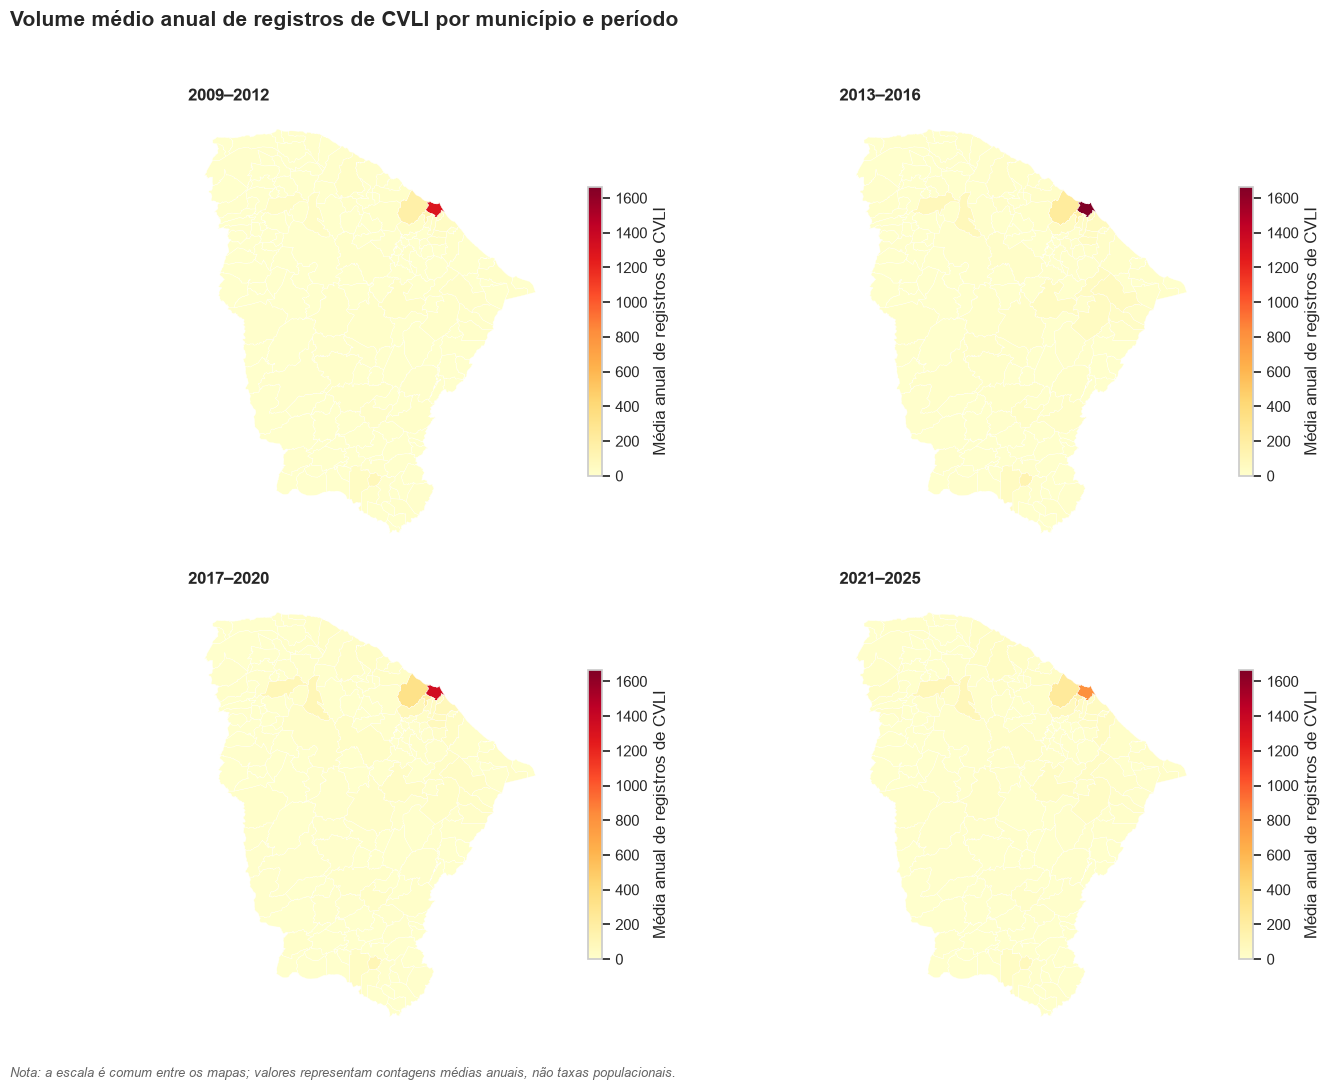

{'status': 'executado',
 'municipios_na_geometria': 184,
 'municipios_sem_geometria': 0}

In [8]:
map_status = {'status': 'não executado'}
try:
    geo_ce = load_municipality_geodata(state='CE', year=2020)
    geo_ce['code_muni'] = pd.to_numeric(geo_ce['code_muni'], errors='coerce').astype('Int64')
    map_metrics = period_metrics.copy()
    map_metrics['code_muni'] = map_metrics['code_muni'].astype('Int64')
    unmatched = set(map_metrics['code_muni']) - set(geo_ce['code_muni'])
    assert not unmatched, f'Municípios sem geometria: {sorted(unmatched)}'
    fig, axes = plot_municipality_period_maps(geo_ce, map_metrics)
    plt.show()
    map_status = {
        'status': 'executado',
        'municipios_na_geometria': int(geo_ce['code_muni'].nunique()),
        'municipios_sem_geometria': len(unmatched),
    }
except Exception as exc:
    map_status = {'status': 'não disponível', 'motivo': f'{type(exc).__name__}: {exc}'}
    print('Os mapas não foram renderizados neste ambiente:', map_status['motivo'])
map_status

## Takeaways

### 8. Síntese dos resultados executados

In [9]:
peak = annual_state.loc[annual_state['total_cvli'].idxmax()]
top_period = concentration.sort_values('top_5_pct', ascending=False).iloc[0]
persistent = top5_persistence.iloc[0]

takeaways = pd.DataFrame([
    ['Base e painel', f"{len(df):,} registros foram preservados; o painel completo possui {len(panel):,} combinações município–ano."],
    ['Pico anual', f"O maior volume anual observado ocorreu em {int(peak['ano'])}, com {int(peak['total_cvli']):,} registros."],
    ['Concentração', f"O maior percentual concentrado nos cinco municípios líderes ocorreu em {top_period['periodo']} ({top_period['top_5_pct']:.2f}%)."],
    ['Persistência', f"{persistent['municipio']} aparece entre os cinco maiores volumes em {int(persistent['anos_no_top5'])} anos."],
    ['Interpretação', 'Os resultados são contagens de registros; sem população, não medem risco relativo entre municípios.'],
], columns=['dimensão', 'síntese'])
display(takeaways)

print('Próxima extensão prevista: fornecer população com colunas code_muni, ano e populacao e executar add_population_rates(panel, populacao).')

,dimensão,síntese
0,Base e painel,"59,340 registros foram preservados; o painel c..."
1,Pico anual,O maior volume anual observado ocorreu em 2017...
2,Concentração,O maior percentual concentrado nos cinco munic...
3,Persistência,Fortaleza aparece entre os cinco maiores volum...
4,Interpretação,Os resultados são contagens de registros; sem ...


Próxima extensão prevista: fornecer população com colunas code_muni, ano e populacao e executar add_population_rates(panel, populacao).


### 9. Validação final e contrato para a próxima etapa

In [10]:
population_schema = pd.DataFrame(columns=['code_muni', 'ano', 'populacao'])
validation = {
    'notebook_scope': 'CVLI',
    'raw_rows': len(df),
    'panel_rows': len(panel),
    'panel_expected_rows': 184 * 17,
    'raw_panel_reconciled': int(panel['total_cvli'].sum()) == len(df),
    'panel_key_unique': not panel.duplicated(['code_muni', 'ano']).any(),
    'regional_coverage_complete': diagnostics['municipalities_not_in_planning'] == [],
    'map_status': map_status['status'],
    'population_schema': list(population_schema.columns),
}
display(pd.Series(validation, name='status').to_frame())

assert validation['raw_panel_reconciled']
assert validation['panel_key_unique']
assert validation['regional_coverage_complete']
print('Validações estruturais concluídas. A análise permanece descritiva e sem taxas populacionais.')

,status
notebook_scope,CVLI
raw_rows,59340
panel_rows,3128
panel_expected_rows,3128
raw_panel_reconciled,True
panel_key_unique,True
regional_coverage_complete,True
map_status,executado
population_schema,"[code_muni, ano, populacao]"


Validações estruturais concluídas. A análise permanece descritiva e sem taxas populacionais.
